# BrightWave Workforce Analysis Using Python

## Project Objective
Analyze fictional employee data to understand workforce distribution, salary patterns, experience, demographics, and employee status.

**Tools:** Python, Pandas, Matplotlib

This project intentionally uses beginner-friendly Python and focuses on practical Data Analyst tasks.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/brightwave_employee_data.csv")
df.head()


,Employee_ID,Department,Age,Gender,Experience_Years,Salary,Location,Status
0,BW001,IT,23,Female,1,51000,Nashik,Active
1,BW002,Operations,24,Female,0,39000,Nashik,Active
2,BW003,Sales,23,Female,0,52000,Hyderabad,Active
3,BW004,Sales,39,Female,8,66000,Hyderabad,Active
4,BW005,HR,39,Male,13,83000,Pune,Active


## 1. Understand the dataset

In [2]:
print("Rows and columns:", df.shape)
print("\nColumn information:")
df.info()


Rows and columns: (120, 8)

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Employee_ID       120 non-null    str  
 1   Department        120 non-null    str  
 2   Age               120 non-null    int64
 3   Gender            120 non-null    str  
 4   Experience_Years  120 non-null    int64
 5   Salary            120 non-null    int64
 6   Location          120 non-null    str  
 7   Status            120 non-null    str  
dtypes: int64(3), str(5)
memory usage: 7.6 KB


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()


Missing values:
Employee_ID         0
Department          0
Age                 0
Gender              0
Experience_Years    0
Salary              0
Location            0
Status              0
dtype: int64

Basic statistics:


,Age,Experience_Years,Salary
count,120.000000,120.000000,120.000000
mean,36.566667,8.241667,72433.333333
std,9.529903,5.932386,19445.132174
min,22.000000,0.000000,39000.000000
25%,29.000000,3.000000,56000.000000
50%,36.000000,8.000000,70000.000000
75%,45.000000,13.000000,89000.000000
max,55.000000,23.000000,117000.000000


## 2. Basic workforce metrics

In [4]:
total_employees = len(df)
active_employees = (df["Status"] == "Active").sum()
exited_employees = (df["Status"] == "Exited").sum()
exit_rate = exited_employees / total_employees * 100
average_salary = df["Salary"].mean()

print(f"Total employees: {total_employees}")
print(f"Active employees: {active_employees}")
print(f"Exited employees: {exited_employees}")
print(f"Exit rate: {exit_rate:.2f}%")
print(f"Average salary: ₹{average_salary:,.0f}")


Total employees: 120
Active employees: 97
Exited employees: 23
Exit rate: 19.17%
Average salary: ₹72,433


## 3. Department-wise workforce

In [5]:
department_count = df["Department"].value_counts()
print(department_count)


Department
Operations    30
Sales         26
HR            24
Finance       21
IT            19
Name: count, dtype: int64


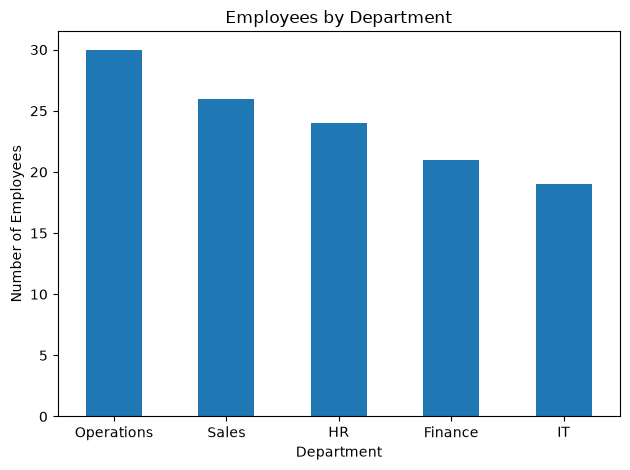

In [6]:
department_count.plot(kind="bar", title="Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/department_distribution.png", dpi=150)
plt.show()


## 4. Salary analysis

In [7]:
salary_by_department = df.groupby("Department")["Salary"].mean().sort_values(ascending=False)
print(salary_by_department)


Department
Operations    74900.000000
Sales         74692.307692
IT            73157.894737
HR            70833.333333
Finance       67285.714286
Name: Salary, dtype: float64


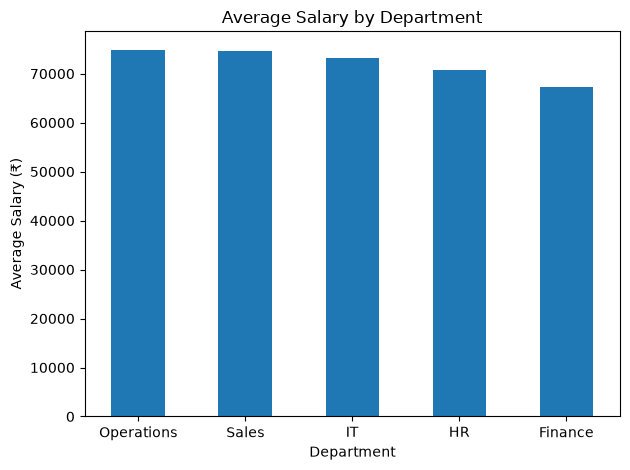

In [8]:
salary_by_department.plot(kind="bar", title="Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/salary_by_department.png", dpi=150)
plt.show()


## 5. Experience analysis

In [9]:
experience_summary = df.groupby("Department")["Experience_Years"].mean().sort_values(ascending=False)
print(experience_summary)


Department
Operations    9.333333
HR            9.041667
Sales         8.461538
IT            6.947368
Finance       6.666667
Name: Experience_Years, dtype: float64


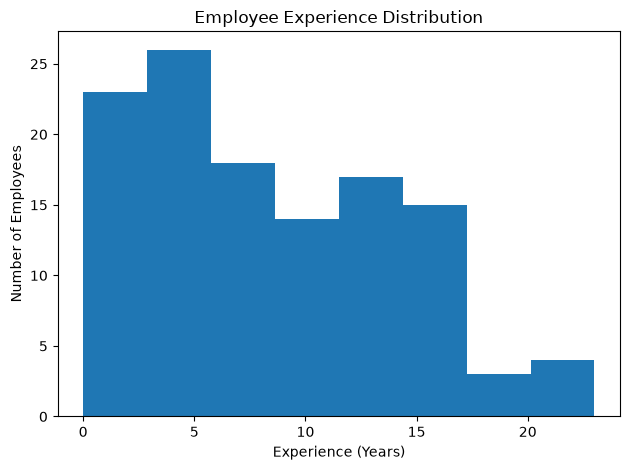

In [10]:
plt.hist(df["Experience_Years"], bins=8)
plt.title("Employee Experience Distribution")
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig("../images/experience_distribution.png", dpi=150)
plt.show()


## 6. Gender and location analysis

In [11]:
print("Gender distribution:")
print(df["Gender"].value_counts())

print("\nLocation distribution:")
print(df["Location"].value_counts())


Gender distribution:
Gender
Female    63
Male      57
Name: count, dtype: int64

Location distribution:
Location
Nashik       26
Bengaluru    26
Hyderabad    24
Mumbai       23
Pune         21
Name: count, dtype: int64


## 7. Employee status

In [12]:
status_count = df["Status"].value_counts()
print(status_count)


Status
Active    97
Exited    23
Name: count, dtype: int64


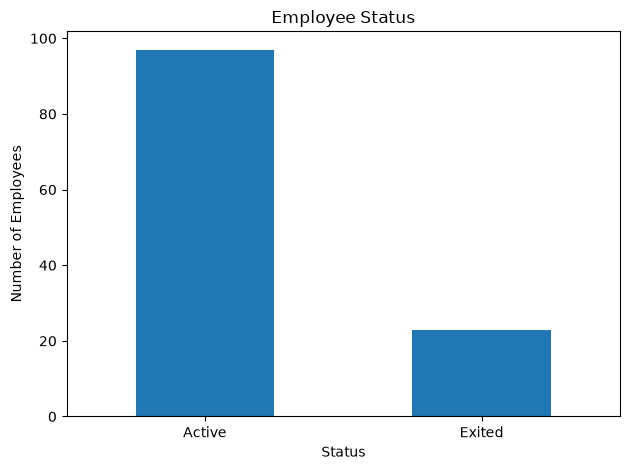

In [13]:
status_count.plot(kind="bar", title="Employee Status")
plt.xlabel("Status")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/employee_status.png", dpi=150)
plt.show()


## 8. Key business insights

The analysis can be used to identify:
- Which departments have the largest workforce.
- Which departments have higher average salaries.
- How employee experience is distributed.
- Which locations have more employees.
- The proportion of active and exited employees.

These findings can support basic workforce planning and operational monitoring.
